In [104]:
import csv
import random
from collections import Counter
from pathlib import Path
from typing import Iterable

import networkx as nx
import numpy as np
from gensim.models import Word2Vec
from rdflib import Graph, Namespace, URIRef
from rdflib.namespace import OWL, RDF, RDFS
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import networkx as nx


1. Load the files

In [105]:
HI = Namespace("http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/")

TTL_FILES = [
    "hi_ontology.ttl",
    "hi_extension.ttl",
    "hi_instances.ttl",
]

OUTPUT_DIR = Path("kg_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def load_graph(files: Iterable[str]) -> Graph:
    g = Graph()
    for file in files:
        path = Path(file)
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {file}")
        g.parse(path, format="turtle")
    return g

2. SPARQL Queries

In [106]:
def run_query(graph: Graph, query: str):
    return list(graph.query(query))


def save_query_results(rows, headers, filepath: Path) -> None:
    with filepath.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for row in rows:
            writer.writerow([str(x) for x in row])


def short_uri(value) -> str:
    value = str(value)
    if "#" in value:
        return value.split("#")[-1]
    return value.split("/")[-1]

SPARQL_QUERIES = {
    # -----------------------------
    # SUPPORT QUERY 1
    # -----------------------------
    "q1_papers_per_scenario": {
        "description": "Count how many papers are linked to each main scenario.",
        "headers": ["scenario", "paperCount"],
        "query": """
        PREFIX hi: <http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/>

        SELECT ?scenario (COUNT(DISTINCT ?paper) AS ?paperCount)
        WHERE {
          ?paper a hi:ResearchPaper ;
                 hi:relevantToScenario ?scenario .
        }
        GROUP BY ?scenario
        ORDER BY DESC(?paperCount)
        """
    },

    # -----------------------------
    # COMPLEX QUERY 1
    # 4+ triple patterns + multiple operators
    # -----------------------------
    "q2_papers_by_scenario_autonomy_trust_pattern": {
        "description": "Count papers by scenario, autonomy level, and trust state, with explanation-pattern summaries.",
        "headers": ["scenario", "autonomyLevel", "trustState", "paperCount", "patterns"],
        "query": """
        PREFIX hi: <http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/>

        SELECT ?scenario ?autonomyLevel ?trustState
               (COUNT(DISTINCT ?paper) AS ?paperCount)
               (GROUP_CONCAT(DISTINCT REPLACE(STR(?pattern), "^.*[#/]", ""); separator=", ") AS ?patterns)
        WHERE {
          ?paper a hi:ResearchPaper ;
                 hi:relevantToScenario ?scenario ;
                 hi:hasAutonomyLevel ?autonomyLevel ;
                 hi:hasTrustState ?trustState .
          OPTIONAL { ?paper hi:usesExplanationPattern ?pattern . }
        }
        GROUP BY ?scenario ?autonomyLevel ?trustState
        ORDER BY ?scenario DESC(?paperCount)
        """
    },

    # -----------------------------
    # COMPLEX QUERY 2
    # 4+ triple patterns + multiple operators
    # -----------------------------
    "q3_scenario_actor_capability_ethics": {
        "description": "Relate scenarios to actors, actor capabilities, ethical considerations, and linked paper counts.",
        "headers": ["scenario", "actor", "capabilities", "ethics", "paperCount"],
        "query": """
        PREFIX hi: <http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/>

        SELECT ?scenario ?actor
               (GROUP_CONCAT(DISTINCT REPLACE(STR(?cap), "^.*[#/]", ""); separator=", ") AS ?capabilities)
               (GROUP_CONCAT(DISTINCT REPLACE(STR(?ethic), "^.*[#/]", ""); separator=", ") AS ?ethics)
               (COUNT(DISTINCT ?paper) AS ?paperCount)
        WHERE {
          ?paper a hi:ResearchPaper ;
                 hi:relevantToScenario ?scenario .
          ?scenario hi:involvesActor ?actor ;
                    hi:hasEthicalConsideration ?ethic .
          OPTIONAL { ?actor hi:capability ?cap . }
          FILTER NOT EXISTS { ?scenario a hi:ScenarioVariant . }
        }
        GROUP BY ?scenario ?actor
        ORDER BY ?scenario DESC(?paperCount)
        """
    },

    # -----------------------------
    # COMPLEX QUERY 3
    # 4+ triple patterns + multiple operators
    # -----------------------------
    "q4_cross_domain_paper_profiles": {
        "description": "Find papers linked to more than one scenario, together with trust, autonomy, and explanation-pattern profiles.",
        "headers": ["paper", "scenarioCount", "scenarios", "autonomyLevels", "trustStates", "patterns"],
        "query": """
        PREFIX hi: <http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/>

        SELECT ?paper
               (COUNT(DISTINCT ?scenario) AS ?scenarioCount)
               (GROUP_CONCAT(DISTINCT REPLACE(STR(?scenario), "^.*[#/]", ""); separator=", ") AS ?scenarios)
               (GROUP_CONCAT(DISTINCT REPLACE(STR(?autonomyLevel), "^.*[#/]", ""); separator=", ") AS ?autonomyLevels)
               (GROUP_CONCAT(DISTINCT REPLACE(STR(?trustState), "^.*[#/]", ""); separator=", ") AS ?trustStates)
               (GROUP_CONCAT(DISTINCT REPLACE(STR(?pattern), "^.*[#/]", ""); separator=", ") AS ?patterns)
        WHERE {
          ?paper a hi:ResearchPaper ;
                 hi:relevantToScenario ?scenario ;
                 hi:hasAutonomyLevel ?autonomyLevel ;
                 hi:hasTrustState ?trustState .
          OPTIONAL { ?paper hi:usesExplanationPattern ?pattern . }
        }
        GROUP BY ?paper
        HAVING (COUNT(DISTINCT ?scenario) > 1)
        ORDER BY DESC(?scenarioCount) ?paper
        """
    },

    # -----------------------------
    # SUPPORT QUERY 2
    # good for heatmap
    # -----------------------------
    "q5_scenario_autonomy_heatmap": {
        "description": "Count papers by scenario and autonomy level.",
        "headers": ["scenario", "autonomyLevel", "paperCount"],
        "query": """
        PREFIX hi: <http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/>

        SELECT ?scenario ?autonomyLevel (COUNT(DISTINCT ?paper) AS ?paperCount)
        WHERE {
          ?paper a hi:ResearchPaper ;
                 hi:relevantToScenario ?scenario ;
                 hi:hasAutonomyLevel ?autonomyLevel .
        }
        GROUP BY ?scenario ?autonomyLevel
        ORDER BY ?scenario ?autonomyLevel
        """
    },

    # -----------------------------
    # SUPPORT QUERY 3
    # good for heatmap
    # -----------------------------
    "q6_scenario_trust_heatmap": {
        "description": "Count papers by scenario and trust state.",
        "headers": ["scenario", "trustState", "paperCount"],
        "query": """
        PREFIX hi: <http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/>

        SELECT ?scenario ?trustState (COUNT(DISTINCT ?paper) AS ?paperCount)
        WHERE {
          ?paper a hi:ResearchPaper ;
                 hi:relevantToScenario ?scenario ;
                 hi:hasTrustState ?trustState .
        }
        GROUP BY ?scenario ?trustState
        ORDER BY ?scenario ?trustState
        """
    }
}



3. Compute Metrics

In [107]:
def count_query(graph: Graph, query: str) -> int:
    return int(list(graph.query(query))[0][0])


def count_instances_of_root(graph: Graph, root_uri: URIRef, exclude_uri: URIRef | None = None) -> int:
    exclude_filter = f"FILTER(?t != <{exclude_uri}>)" if exclude_uri else ""
    return count_query(graph, f"""
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
        SELECT (COUNT(DISTINCT ?x) AS ?count)
        WHERE {{
          ?x a ?t .
          ?t rdfs:subClassOf* <{root_uri}> .
          {exclude_filter}
        }}
    """)

def compute_basic_metrics(graph: Graph) -> dict:
    metrics = {}

    metrics["total_triples"] = len(graph)

    metrics["classes"] = count_query(graph, """
        PREFIX owl: <http://www.w3.org/2002/07/owl#>
        SELECT (COUNT(DISTINCT ?c) AS ?count)
        WHERE { ?c a owl:Class . }
    """)

    metrics["object_properties"] = count_query(graph, """
        PREFIX owl: <http://www.w3.org/2002/07/owl#>
        SELECT (COUNT(DISTINCT ?p) AS ?count)
        WHERE { ?p a owl:ObjectProperty . }
    """)

    metrics["datatype_properties"] = count_query(graph, """
        PREFIX owl: <http://www.w3.org/2002/07/owl#>
        SELECT (COUNT(DISTINCT ?p) AS ?count)
        WHERE { ?p a owl:DatatypeProperty . }
    """)

    metrics["named_individuals"] = count_query(graph, """
        PREFIX owl: <http://www.w3.org/2002/07/owl#>
        SELECT (COUNT(DISTINCT ?i) AS ?count)
        WHERE { ?i a owl:NamedIndividual . }
    """)

    metrics["research_papers"] = count_query(graph, f"""
        PREFIX hi: <{HI}>
        SELECT (COUNT(DISTINCT ?x) AS ?count)
        WHERE {{ ?x a hi:ResearchPaper . }}
    """)

    # subclass-aware counts
    metrics["main_scenarios"] = count_instances_of_root(graph, HI.Scenario, exclude_uri=HI.ScenarioVariant)

    metrics["scenario_variants"] = count_query(graph, f"""
        PREFIX hi: <{HI}>
        SELECT (COUNT(DISTINCT ?x) AS ?count)
        WHERE {{ ?x a hi:ScenarioVariant . }}
    """)

    metrics["actors"] = count_instances_of_root(graph, HI.Actor)

    # annotation coverage metrics
    metrics["trust_annotations"] = count_query(graph, f"""
        PREFIX hi: <{HI}>
        SELECT (COUNT(DISTINCT ?paper) AS ?count)
        WHERE {{
          ?paper a hi:ResearchPaper ;
                 hi:hasTrustState ?trustState .
        }}
    """)

    metrics["autonomy_annotations"] = count_query(graph, f"""
        PREFIX hi: <{HI}>
        SELECT (COUNT(DISTINCT ?paper) AS ?count)
        WHERE {{
          ?paper a hi:ResearchPaper ;
                 hi:hasAutonomyLevel ?autonomyLevel .
        }}
    """)

    metrics["explanation_pattern_annotations"] = count_query(graph, f"""
        PREFIX hi: <{HI}>
        SELECT (COUNT(DISTINCT ?paper) AS ?count)
        WHERE {{
          ?paper a hi:ResearchPaper ;
                 hi:usesExplanationPattern ?pattern .
        }}
    """)

    metrics["external_links_total"] = count_query(graph, """
        SELECT (COUNT(*) AS ?count)
        WHERE {
          ?s ?p ?o .
          FILTER(isIRI(?o))
          FILTER(
            STRSTARTS(STR(?o), "http://dbpedia.org/") ||
            STRSTARTS(STR(?o), "https://dbpedia.org/") ||
            STRSTARTS(STR(?o), "http://www.wikidata.org/") ||
            STRSTARTS(STR(?o), "https://www.wikidata.org/") ||
            STRSTARTS(STR(?o), "https://orkg.org/") ||
            STRSTARTS(STR(?o), "http://orkg.org/") ||
            STRSTARTS(STR(?o), "https://doi.org/") ||
            STRSTARTS(STR(?o), "http://doi.org/") ||
            STRSTARTS(STR(?o), "http://schema.org/") ||
            STRSTARTS(STR(?o), "https://schema.org/") ||
            STRSTARTS(STR(?o), "http://xmlns.com/foaf/") ||
            STRSTARTS(STR(?o), "http://purl.org/")
          )
        }
    """)

    metrics["external_kb_links_strict"] = count_query(graph, """
        SELECT (COUNT(*) AS ?count)
        WHERE {
          ?s ?p ?o .
          FILTER(isIRI(?o))
          FILTER(
            STRSTARTS(STR(?o), "http://dbpedia.org/") ||
            STRSTARTS(STR(?o), "https://dbpedia.org/") ||
            STRSTARTS(STR(?o), "http://www.wikidata.org/") ||
            STRSTARTS(STR(?o), "https://www.wikidata.org/") ||
            STRSTARTS(STR(?o), "https://orkg.org/") ||
            STRSTARTS(STR(?o), "http://orkg.org/") ||
            STRSTARTS(STR(?o), "https://doi.org/") ||
            STRSTARTS(STR(?o), "http://doi.org/")
          )
        }
    """)

    metrics["dbpedia_links"] = count_query(graph, """
        SELECT (COUNT(*) AS ?count)
        WHERE {
          ?s ?p ?o .
          FILTER(isIRI(?o))
          FILTER(
            STRSTARTS(STR(?o), "http://dbpedia.org/") ||
            STRSTARTS(STR(?o), "https://dbpedia.org/")
          )
        }
    """)

    metrics["wikidata_links"] = count_query(graph, """
        SELECT (COUNT(*) AS ?count)
        WHERE {
          ?s ?p ?o .
          FILTER(isIRI(?o))
          FILTER(
            STRSTARTS(STR(?o), "http://www.wikidata.org/") ||
            STRSTARTS(STR(?o), "https://www.wikidata.org/")
          )
        }
    """)

    metrics["orkg_links"] = count_query(graph, """
        SELECT (COUNT(*) AS ?count)
        WHERE {
          ?s ?p ?o .
          FILTER(isIRI(?o))
          FILTER(
            STRSTARTS(STR(?o), "http://orkg.org/") ||
            STRSTARTS(STR(?o), "https://orkg.org/")
          )
        }
    """)

    metrics["doi_links"] = count_query(graph, """
        SELECT (COUNT(*) AS ?count)
        WHERE {
          ?s ?p ?o .
          FILTER(isIRI(?o))
          FILTER(
            STRSTARTS(STR(?o), "http://doi.org/") ||
            STRSTARTS(STR(?o), "https://doi.org/")
          )
        }
    """)

    return metrics


def build_network(graph: Graph) -> nx.DiGraph:
    dg = nx.DiGraph()
    for s, p, o in graph:
        if isinstance(s, URIRef) and isinstance(o, URIRef):
            dg.add_edge(str(s), str(o), predicate=str(p))
    return dg


def get_instance_node_set(graph: Graph) -> set[str]:
    rows = graph.query(f"""
        PREFIX hi: <{HI}>
        PREFIX owl: <http://www.w3.org/2002/07/owl#>
        SELECT DISTINCT ?x
        WHERE {{
          ?x a ?t .
          FILTER(isIRI(?x))
          FILTER(
            ?t != owl:Class &&
            ?t != owl:ObjectProperty &&
            ?t != owl:DatatypeProperty &&
            ?t != owl:NamedIndividual
          )
        }}
    """)
    return {str(row[0]) for row in rows}


def compute_network_metrics(graph: Graph) -> tuple[dict, list[tuple[str, int]], list[tuple[str, int]]]:
    dg = build_network(graph)

    avg_degree = 0.0
    if dg.number_of_nodes() > 0:
        avg_degree = sum(dict(dg.degree()).values()) / dg.number_of_nodes()

    weak_components = list(nx.weakly_connected_components(dg)) if dg.number_of_nodes() > 0 else []
    largest_weak_component = max((len(c) for c in weak_components), default=0)

    metrics = {
        "iri_nodes": dg.number_of_nodes(),
        "iri_edges": dg.number_of_edges(),
        "density": nx.density(dg) if dg.number_of_nodes() > 1 else 0.0,
        "avg_degree": round(avg_degree, 3),
        "weak_components": len(weak_components),
        "largest_weak_component": largest_weak_component,
    }

    instance_nodes = get_instance_node_set(graph)
    top_nodes = sorted(
        [(n, d) for n, d in dg.degree if n in instance_nodes],
        key=lambda x: x[1],
        reverse=True
    )[:15]

    pred_counter = Counter()
    for _, _, p_data in dg.edges(data=True):
        pred_counter[short_uri(p_data["predicate"])] += 1
    top_predicates = pred_counter.most_common(15)

    return metrics, top_nodes, top_predicates

4. Run embeddings / simple link prediction

In [108]:
def get_nodes_by_type(graph: Graph, class_uri: URIRef) -> list[str]:
    return [str(row[0]) for row in graph.query(
        """
        SELECT ?x WHERE { ?x a ?cls . }
        """,
        initBindings={"cls": class_uri}
    )]


def build_adjacency(graph: Graph) -> dict[str, list[tuple[str, str]]]:
    adj: dict[str, list[tuple[str, str]]] = {}
    for s, p, o in graph:
        if isinstance(s, URIRef) and isinstance(o, URIRef):
            s_str = str(s)
            p_str = str(p)
            o_str = str(o)
            adj.setdefault(s_str, []).append((p_str, o_str))
            adj.setdefault(o_str, []).append((p_str + "_inv", s_str))
    return adj


def make_random_walks(adj: dict[str, list[tuple[str, str]]], starts: list[str], num_walks: int = 80, depth: int = 6) -> list[list[str]]:
    walks = []

    for start in starts:
        for _ in range(num_walks):
            current = start
            walk = [short_uri(current)]
            for _ in range(depth):
                neighbors = adj.get(current, [])
                if not neighbors:
                    break
                pred, nxt = random.choice(neighbors)
                walk.extend([short_uri(pred), short_uri(nxt)])
                current = nxt
            walks.append(walk)

    return walks


def train_embeddings(walks: list[list[str]]) -> Word2Vec:
    return Word2Vec(
        sentences=walks,
        vector_size=64,
        window=5,
        min_count=1,
        sg=1,
        workers=1,
        epochs=50,
        seed=RANDOM_SEED
    )


def predict_missing_paper_scenario_links(graph: Graph, model: Word2Vec) -> list[tuple[float, str, str]]:
    papers = get_nodes_by_type(graph, HI.ResearchPaper)

    scenarios = [str(row[0]) for row in graph.query(f"""
        PREFIX hi: <{HI}>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

        SELECT DISTINCT ?s
        WHERE {{
          ?s a ?t .
          ?t rdfs:subClassOf* hi:Scenario .
          FILTER(?t != hi:ScenarioVariant)
        }}
    """)]

    existing_links = set(
        (str(row[0]), str(row[1]))
        for row in graph.query(f"""
            PREFIX hi: <{HI}>
            SELECT ?paper ?scenario
            WHERE {{
              ?paper a hi:ResearchPaper ;
                     hi:relevantToScenario ?scenario .
            }}
        """)
    )

    candidates = []
    for p in papers:
        for s in scenarios:
            if (p, s) in existing_links:
                continue
            p_key = short_uri(p)
            s_key = short_uri(s)
            if p_key in model.wv and s_key in model.wv:
                score = float(cosine_similarity([model.wv[p_key]], [model.wv[s_key]])[0][0])
                candidates.append((score, p_key, s_key))

    candidates.sort(reverse=True)
    return candidates[:15]


def most_similar_papers(graph: Graph, model: Word2Vec, target_paper: str) -> list[tuple[str, float]]:
    results = []
    for node, score in model.wv.most_similar(target_paper, topn=20):
        if node.startswith("Paper"):
            results.append((node, float(score)))
    return results[:10]

5. Print Results

In [109]:
def print_section(title: str) -> None:
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_table(rows, headers) -> None:
    if not rows:
        print("(no results)")
        return

    str_rows = [[str(x) for x in row] for row in rows]
    widths = [len(h) for h in headers]

    for row in str_rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(cell))

    header_line = " | ".join(h.ljust(widths[i]) for i, h in enumerate(headers))
    sep_line = "-+-".join("-" * widths[i] for i in range(len(headers)))

    print(header_line)
    print(sep_line)
    for row in str_rows:
        print(" | ".join(row[i].ljust(widths[i]) for i in range(len(headers))))


6. Save results to files

In [110]:
def save_metrics(metrics: dict, filepath: Path) -> None:
    with filepath.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["metric", "value"])
        for k, v in metrics.items():
            writer.writerow([k, v])


def save_list_rows(rows: list[tuple], headers: list[str], filepath: Path) -> None:
    with filepath.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for row in rows:
            writer.writerow(row)


7. Main

In [111]:
# plotting helpers
def rows_to_df(rows, headers):
    data = [[str(x) for x in row] for row in rows]
    return pd.DataFrame(data, columns=headers)


def add_value_labels(ax, horizontal=False, decimals=0):
    for p in ax.patches:
        value = p.get_width() if horizontal else p.get_height()
        if horizontal:
            ax.text(
                value + 0.02,
                p.get_y() + p.get_height() / 2,
                f"{value:.{decimals}f}" if decimals else f"{int(value)}",
                va="center"
            )
        else:
            ax.text(
                p.get_x() + p.get_width() / 2,
                value + 0.05,
                f"{value:.{decimals}f}" if decimals else f"{int(value)}",
                ha="center"
            )


def plot_bar_chart(rows, headers, x_col, y_col, title, xlabel, ylabel, rotation=20):
    if not rows:
        print(f"[skip] No data for: {title}")
        return

    df = rows_to_df(rows, headers)
    df[x_col] = df[x_col].map(short_uri)
    df[y_col] = df[y_col].astype(int)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(df[x_col], df[y_col])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(df[x_col], rotation=rotation, ha="right")
    add_value_labels(ax)
    plt.tight_layout()
    plt.show()


def plot_horizontal_bar_chart(rows, headers, label_col, value_col, title, xlabel, ylabel, decimals=0):
    if not rows:
        print(f"[skip] No data for: {title}")
        return

    df = rows_to_df(rows, headers)
    df[label_col] = df[label_col].map(short_uri)
    df[value_col] = df[value_col].astype(float)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.5 * len(df))))
    ax.barh(df[label_col], df[value_col])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    add_value_labels(ax, horizontal=True, decimals=decimals)
    plt.tight_layout()
    plt.show()


def plot_heatmap(rows, headers, row_col, col_col, value_col, title, xlabel, ylabel, binary=False):
    if not rows:
        print(f"[skip] No data for: {title}")
        return

    df = rows_to_df(rows, headers)
    df[row_col] = df[row_col].map(short_uri)
    df[col_col] = df[col_col].map(short_uri)

    if binary:
        df["value"] = 1
        pivot = df.pivot_table(index=row_col, columns=col_col, values="value", aggfunc="max", fill_value=0)
    else:
        df[value_col] = df[value_col].astype(int)
        pivot = df.pivot_table(index=row_col, columns=col_col, values=value_col, aggfunc="sum", fill_value=0)

    fig_w = max(7, 1.2 * len(pivot.columns))
    fig_h = max(3.5, 0.7 * len(pivot.index))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, str(int(pivot.iat[i, j])), ha="center", va="center")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Presence" if binary else "Paper count")

    plt.tight_layout()
    plt.show()


def plot_top_predicted_links(predicted_links, top_n=10):
    if not predicted_links:
        print("[skip] No predicted links to plot.")
        return

    top = predicted_links[:top_n]
    labels = [f"{short_uri(paper)} → {short_uri(scenario)}" for score, paper, scenario in top][::-1]
    values = [score for score, paper, scenario in top][::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels, values)
    ax.set_title(f"Top {top_n} Predicted Missing Paper–Scenario Links")
    ax.set_xlabel("Embedding similarity score")
    ax.set_ylabel("Predicted link")
    add_value_labels(ax, horizontal=True, decimals=3)
    plt.tight_layout()
    plt.show()

def plot_metrics_bar(metrics: dict, keys: list[str], title: str):
    rows = [(k, metrics[k]) for k in keys if k in metrics]

    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [k.replace("_", " ").title() for k, _ in rows]
    values = [v for _, v in rows]

    ax.bar(labels, values)
    ax.set_title(title)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Value")
    ax.set_xticklabels(labels, rotation=30, ha="right")

    for i, v in enumerate(values):
        ax.text(i, v + (0.01 * max(values) if max(values) else 0.1), str(v), ha="center")

    plt.tight_layout()
    plt.show()


def plot_top_predicates(top_predicates: list[tuple[str, int]], top_n: int = 10):
    rows = top_predicates[:top_n]
    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [r[0] for r in rows][::-1]
    values = [r[1] for r in rows][::-1]

    ax.barh(labels, values)
    ax.set_title(f"Top {top_n} Predicates by Frequency")
    ax.set_xlabel("Count")
    ax.set_ylabel("Predicate")

    for i, v in enumerate(values):
        ax.text(v + 0.1, i, str(v), va="center")

    plt.tight_layout()
    plt.show()


def save_manual_validation_template(predicted_links, filepath: Path, top_n: int = 10):
    rows = [
        (round(score, 6), paper, scenario, "", "", "")
        for score, paper, scenario in predicted_links[:top_n]
    ]
    save_list_rows(
        rows,
        ["score", "paper", "scenario", "plausible_yes_no", "confidence_low_med_high", "notes"],
        filepath
    )


STEP 1 - LOADING TTL FILES
Loaded graph with 1109 triples from 3 files.

STEP 2 - RUNNING SPARQL QUERIES

q1_papers_per_scenario: Count how many papers are linked to each main scenario.
scenario                                                                                         | paperCount
-------------------------------------------------------------------------------------------------+-----------
http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/HealthcareDiagnosisTeam | 9         
http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/ChildEducationTeam      | 5         
http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/ResearchHITeam          | 2         

q2_papers_by_scenario_autonomy_trust_pattern: Count papers by scenario, autonomy level, and trust state, with explanation-pattern summaries.
scenario                                                                                         | autonomyLevel         

/var/folders/6x/rqxd1_wj0xl4l8j7mvnxdx100000gn/T/ipykernel_48627/3751597946.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df[x_col], rotation=rotation, ha="right")


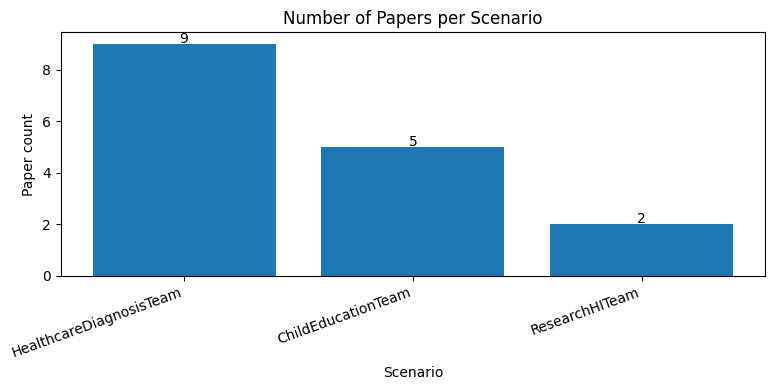

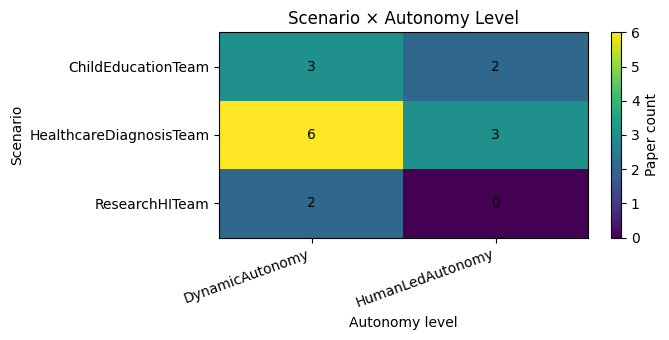

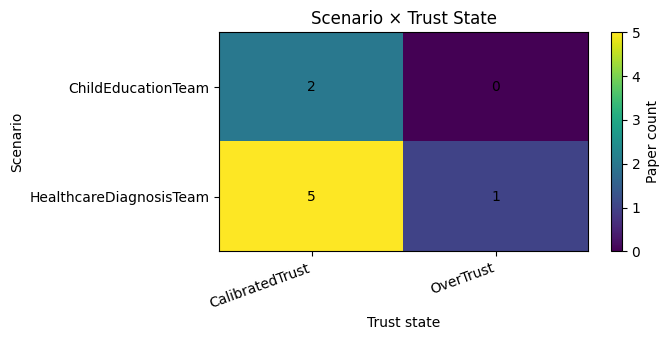

[skip] Cross-domain bar chart skipped because all scenario counts are identical.

STEP 3 - COMPUTING KG METRICS
total_triples: 1109
classes: 31
object_properties: 22
datatype_properties: 4
named_individuals: 55
research_papers: 11
main_scenarios: 3
scenario_variants: 6
actors: 16
trust_annotations: 6
autonomy_annotations: 11
explanation_pattern_annotations: 5
external_links_total: 340
external_kb_links_strict: 321
dbpedia_links: 218
wikidata_links: 92
orkg_links: 0
doi_links: 11


/var/folders/6x/rqxd1_wj0xl4l8j7mvnxdx100000gn/T/ipykernel_48627/3751597946.py:134: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


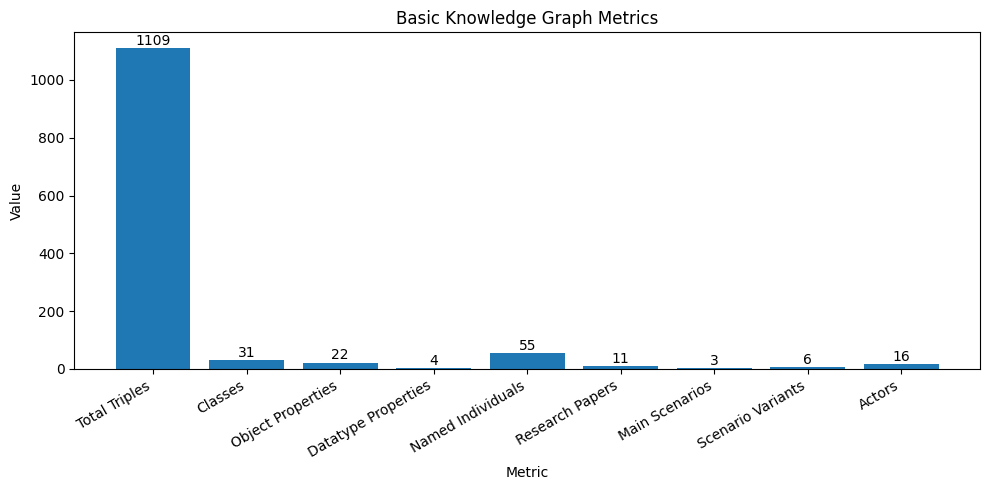


Network metrics:
iri_nodes: 394
iri_edges: 907
density: 0.005857583859676315
avg_degree: 4.604
weak_components: 2
largest_weak_component: 392

Top instance nodes by degree:
node                            | degree
--------------------------------+-------
HealthcareDiagnosisTeam         | 48    
ChildEducationTeam              | 37    
ResearchHITeam                  | 27    
Paper1_TrustFactorsGame         | 23    
Paper10_BRIDGET                 | 21    
HealthcareDiagnosisBestCase     | 21    
Paper2_GazeAwarenessVR          | 20    
HealthcareDiagnosisWorstCase    | 20    
ChildEducationBestCase          | 20    
Paper11_OncologicalRadiotherapy | 20    
Paper8_ExplanationPatterns      | 19    
Paper5_PastEnvironments         | 18    
DynamicAutonomy                 | 18    
DiagnosisAISystem               | 18    
Paper6_SocialAIHealthyLifestyle | 18    


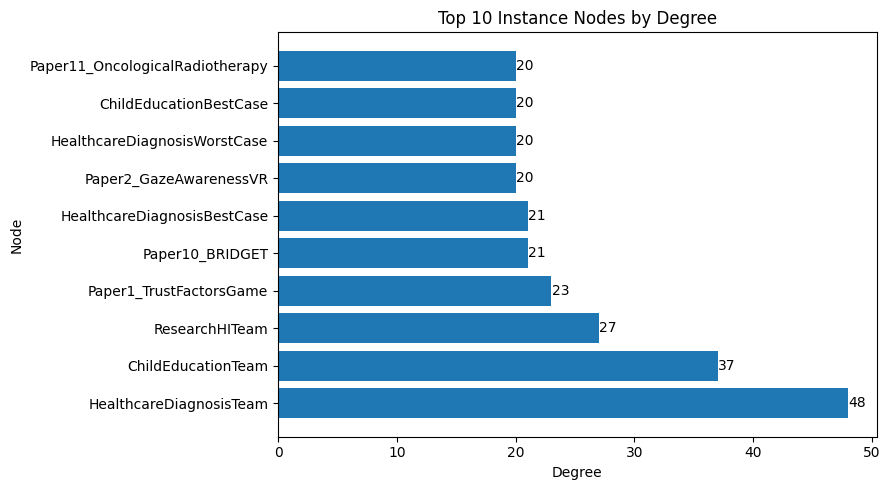


Top predicates:
predicate               | count
------------------------+------
type                    | 227  
seeAlso                 | 155  
subject                 | 101  
closeMatch              | 49   
involvesActor           | 33   
domain                  | 32   
capability              | 26   
range                   | 25   
hasEthicalConsideration | 22   
hasAutonomyLevel        | 20   
subClassOf              | 19   
exactMatch              | 18   
relevantToScenario      | 16   
supportedByPaper        | 16   
hasTrustState           | 15   


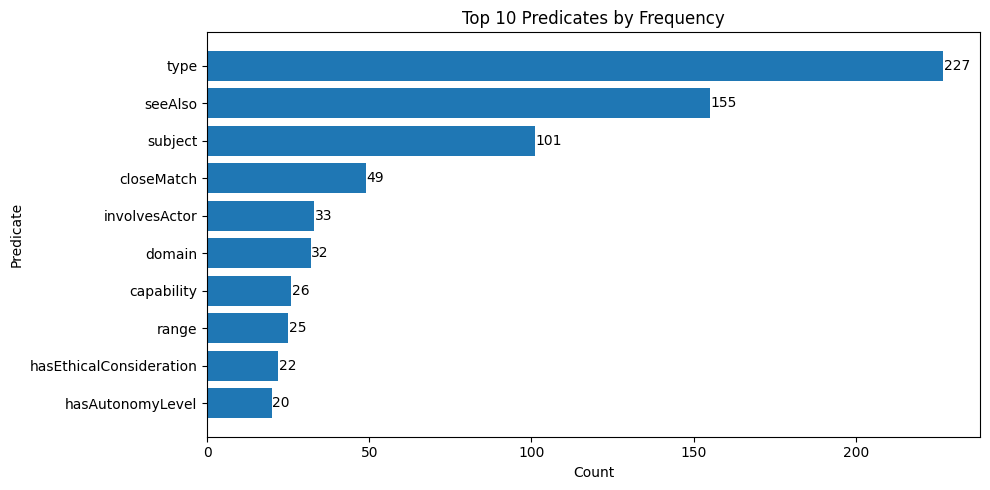


STEP 4 - TRAINING EMBEDDINGS / LINK PREDICTION
Generated 1120 random walks.
Embedding model trained.

STEP 5 - PRINTING SUBSYMBOLIC RESULTS
Top predicted missing paper-scenario links:
score | paper                              | scenario               
------+------------------------------------+------------------------
0.266 | Paper9_FaceMatchingDecisionSupport | ResearchHITeam         
0.233 | Paper10_BRIDGET                    | ResearchHITeam         
0.228 | Paper7_OrganDonationSimulation     | ResearchHITeam         
0.227 | Paper5_PastEnvironments            | HealthcareDiagnosisTeam
0.216 | Paper3_HybridMoralDecisionMaking   | ResearchHITeam         
0.213 | Paper8_ExplanationPatterns         | ResearchHITeam         
0.199 | Paper4_EEGTrustCalibration         | ChildEducationTeam     
0.197 | Paper4_EEGTrustCalibration         | ResearchHITeam         
0.189 | Paper11_OncologicalRadiotherapy    | ChildEducationTeam     
0.171 | Paper7_OrganDonationSimulation     | ChildEducat

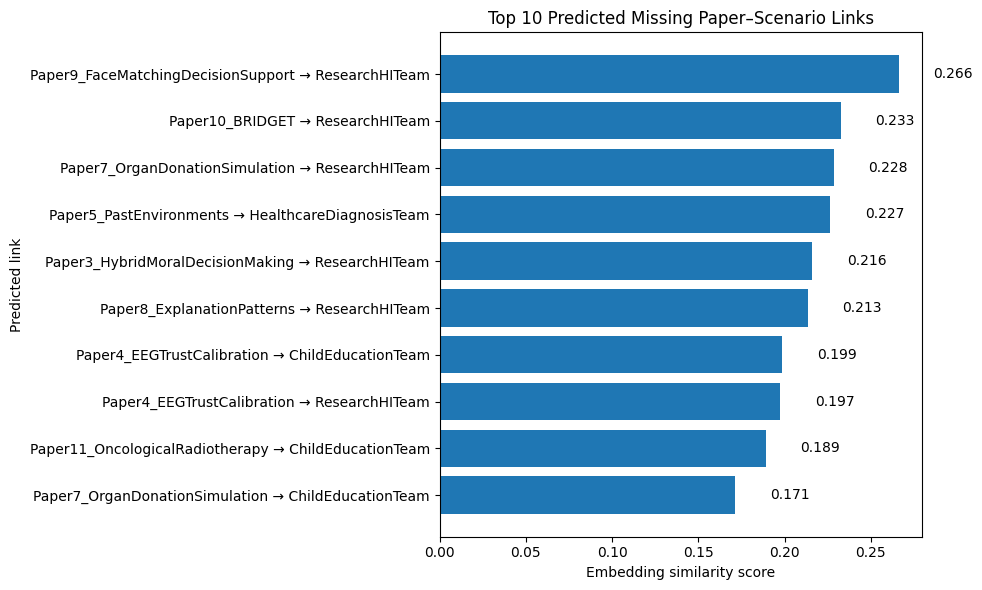


Most similar papers to Paper10_BRIDGET:
(no results)

STEP 6 - SAVING RESULTS
All CSV files saved in: /Users/vlinder/Documents/MSc AI/KGST/KG_project/kg_outputs

Done.


In [112]:
def main() -> None:
    print_section("STEP 1 - LOADING TTL FILES")
    graph = load_graph(TTL_FILES)
    print(f"Loaded graph with {len(graph)} triples from {len(TTL_FILES)} files.")

    print_section("STEP 2 - RUNNING SPARQL QUERIES")
    for name, info in SPARQL_QUERIES.items():
        print(f"\n{name}: {info['description']}")
        rows = run_query(graph, info["query"])
        print_table(rows, info["headers"])
        save_query_results(rows, info["headers"], OUTPUT_DIR / f"{name}.csv")
    
    print_section("STEP 2B - PLOTTING QUERY RESULTS")

    # ---------------------------------
    # Figure 1: corpus coverage
    # ---------------------------------
    rows = run_query(graph, SPARQL_QUERIES["q1_papers_per_scenario"]["query"])
    plot_bar_chart(
        rows,
        SPARQL_QUERIES["q1_papers_per_scenario"]["headers"],
        x_col="scenario",
        y_col="paperCount",
        title="Number of Papers per Scenario",
        xlabel="Scenario",
        ylabel="Paper count",
        rotation=20
    )

    # ---------------------------------
    # Figure 2: scenario × autonomy
    # ---------------------------------
    rows = run_query(graph, SPARQL_QUERIES["q5_scenario_autonomy_heatmap"]["query"])
    plot_heatmap(
        rows,
        SPARQL_QUERIES["q5_scenario_autonomy_heatmap"]["headers"],
        row_col="scenario",
        col_col="autonomyLevel",
        value_col="paperCount",
        title="Scenario × Autonomy Level",
        xlabel="Autonomy level",
        ylabel="Scenario",
        binary=False
    )

    # ---------------------------------
    # Figure 3: scenario × trust
    # ---------------------------------
    rows = run_query(graph, SPARQL_QUERIES["q6_scenario_trust_heatmap"]["query"])
    plot_heatmap(
        rows,
        SPARQL_QUERIES["q6_scenario_trust_heatmap"]["headers"],
        row_col="scenario",
        col_col="trustState",
        value_col="paperCount",
        title="Scenario × Trust State",
        xlabel="Trust state",
        ylabel="Scenario",
        binary=False
    )

    # ---------------------------------
    # Optional figure 4: cross-domain papers
    # only if there is variation in scenarioCount
    # ---------------------------------
    rows = run_query(graph, SPARQL_QUERIES["q4_cross_domain_paper_profiles"]["query"])
    if rows:
        scenario_counts = [int(row[1]) for row in rows]
        if len(set(scenario_counts)) > 1:
            plot_horizontal_bar_chart(
                rows,
                SPARQL_QUERIES["q4_cross_domain_paper_profiles"]["headers"],
                label_col="paper",
                value_col="scenarioCount",
                title="Cross-Domain Papers by Number of Linked Scenarios",
                xlabel="Scenario count",
                ylabel="Paper"
            )
        else:
            print("[skip] Cross-domain bar chart skipped because all scenario counts are identical.")
    

    print_section("STEP 3 - COMPUTING KG METRICS")
    basic_metrics = compute_basic_metrics(graph)
    for k, v in basic_metrics.items():
        print(f"{k}: {v}")
    save_metrics(basic_metrics, OUTPUT_DIR / "basic_metrics.csv")

    # plot scalar KG metrics
    plot_metrics_bar(
        basic_metrics,
        keys=[
            "total_triples",
            "classes",
            "object_properties",
            "datatype_properties",
            "named_individuals",
            "research_papers",
            "main_scenarios",
            "scenario_variants",
            "actors",
            "external_links",
        ],
        title="Basic Knowledge Graph Metrics"
    )

    network_metrics, top_nodes, top_predicates = compute_network_metrics(graph)

    print("\nNetwork metrics:")
    for k, v in network_metrics.items():
        print(f"{k}: {v}")
    save_metrics(network_metrics, OUTPUT_DIR / "network_metrics.csv")

    print("\nTop instance nodes by degree:")
    top_nodes_clean = [(short_uri(n), d) for n, d in top_nodes]
    print_table(top_nodes_clean, ["node", "degree"])
    save_list_rows(top_nodes_clean, ["node", "degree"], OUTPUT_DIR / "top_nodes.csv")

    plot_horizontal_bar_chart(
        top_nodes_clean[:10],
        ["node", "degree"],
        label_col="node",
        value_col="degree",
        title="Top 10 Instance Nodes by Degree",
        xlabel="Degree",
        ylabel="Node"
    )

    print("\nTop predicates:")
    print_table(top_predicates, ["predicate", "count"])
    save_list_rows(top_predicates, ["predicate", "count"], OUTPUT_DIR / "top_predicates.csv")

    plot_top_predicates(top_predicates, top_n=10)
    

    print_section("STEP 4 - TRAINING EMBEDDINGS / LINK PREDICTION")
    papers = get_nodes_by_type(graph, HI.ResearchPaper)
    scenarios = [str(row[0]) for row in graph.query(f"""
        PREFIX hi: <{HI}>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

        SELECT DISTINCT ?s
        WHERE {{
          ?s a ?t .
          ?t rdfs:subClassOf* hi:Scenario .
          FILTER(?t != hi:ScenarioVariant)
        }}
    """)]

    starts = papers + scenarios
    adj = build_adjacency(graph)
    walks = make_random_walks(adj, starts, num_walks=80, depth=6)
    print(f"Generated {len(walks)} random walks.")

    model = train_embeddings(walks)
    print("Embedding model trained.")

    print_section("STEP 5 - PRINTING SUBSYMBOLIC RESULTS")
    predicted_links = predict_missing_paper_scenario_links(graph, model)
    print("Top predicted missing paper-scenario links:")
    print_table([(round(score, 3), paper, scenario) for score, paper, scenario in predicted_links],
                ["score", "paper", "scenario"])
    save_list_rows(
        [(round(score, 6), paper, scenario) for score, paper, scenario in predicted_links],
        ["score", "paper", "scenario"],
        OUTPUT_DIR / "predicted_missing_links.csv"
    )
    plot_top_predicted_links(predicted_links, top_n=10)

    save_manual_validation_template(
        predicted_links,
        OUTPUT_DIR / "predicted_missing_links_manual_validation.csv",
        top_n=10
    )


    target = "Paper10_BRIDGET"
    if target in model.wv:
        similar = most_similar_papers(graph, model, target)
        print(f"\nMost similar papers to {target}:")
        print_table([(paper, round(score, 3)) for paper, score in similar], ["paper", "similarity"])
        save_list_rows(
            [(paper, round(score, 6)) for paper, score in similar],
            ["paper", "similarity"],
            OUTPUT_DIR / "similar_to_paper10_bridget.csv"
        )
    else:
        print(f"\nTarget paper {target} not found in embedding vocabulary.")

    print_section("STEP 6 - SAVING RESULTS")
    print(f"All CSV files saved in: {OUTPUT_DIR.resolve()}")

    print("\nDone.")


if __name__ == "__main__":
    main()